# Notebook 04 — Cost-Aware Strategy Comparison

## Purpose
This notebook compares the three implemented strategies under transaction costs:

- **Baseline Momentum**
- **Ridge Regression**
- **XGBoost**

## Why this matters
A strategy may look strong before costs, but if it trades too frequently, real-world performance can deteriorate.

This notebook compares results at:
- **0 bps**
- **10 bps**
- **20 bps**

## Focus
Compare:
- cumulative return
- annualized return
- Sharpe ratio
- max drawdown
- turnover sensitivity
- practical robustness after costs

In [5]:
import os
import json
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
print("Project root added to path:", PROJECT_ROOT)

from src.plotting import plot_two_series, COLORS

Project root added to path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml


## 1. Load cost-adjusted results

This load:
- baseline cost-adjusted metrics
- Ridge cost-adjusted metrics
- XGBoost cost-adjusted metrics

Each JSON file contains results for:
- `cost_0bps`
- `cost_10bps`
- `cost_20bps`

In [7]:
BASE_DIR = "../experiments/results/exp01_baseline"
RIDGE_DIR = "../experiments/results/exp02_linear_ridge"
XGB_DIR = "../experiments/results/exp03_xgboost"

BASE_COSTS_PATH = os.path.join(BASE_DIR, "metrics_test_2025_with_costs.json")
RIDGE_COSTS_PATH = os.path.join(RIDGE_DIR, "metrics_test_2025_with_costs.json")
XGB_COSTS_PATH = os.path.join(XGB_DIR, "metrics_test_2025_with_costs.json")


def load_json(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)


base_costs = load_json(BASE_COSTS_PATH)
ridge_costs = load_json(RIDGE_COSTS_PATH)
xgb_costs = load_json(XGB_COSTS_PATH)

print("Loaded cost-adjusted test metrics successfully.")

Loaded cost-adjusted test metrics successfully.


## 2. Build a clean comparison table (Test 2025)

Compare the three strategies at each transaction-cost level.

In [8]:
cost_levels = ["cost_0bps", "cost_10bps", "cost_20bps"]
metrics_to_show = [
    "cumulative_return",
    "annualized_return",
    "sharpe_ratio",
    "max_drawdown",
]

rows = []
for cost in cost_levels:
    rows.append({
        "Cost": cost,
        "Baseline_cumulative_return": base_costs[cost]["cumulative_return"],
        "Ridge_cumulative_return": ridge_costs[cost]["cumulative_return"],
        "XGBoost_cumulative_return": xgb_costs[cost]["cumulative_return"],

        "Baseline_annualized_return": base_costs[cost]["annualized_return"],
        "Ridge_annualized_return": ridge_costs[cost]["annualized_return"],
        "XGBoost_annualized_return": xgb_costs[cost]["annualized_return"],

        "Baseline_sharpe_ratio": base_costs[cost]["sharpe_ratio"],
        "Ridge_sharpe_ratio": ridge_costs[cost]["sharpe_ratio"],
        "XGBoost_sharpe_ratio": xgb_costs[cost]["sharpe_ratio"],

        "Baseline_max_drawdown": base_costs[cost]["max_drawdown"],
        "Ridge_max_drawdown": ridge_costs[cost]["max_drawdown"],
        "XGBoost_max_drawdown": xgb_costs[cost]["max_drawdown"],
    })

cost_table = pd.DataFrame(rows)
display(cost_table)

,Cost,Baseline_cumulative_return,Ridge_cumulative_return,XGBoost_cumulative_return,Baseline_annualized_return,Ridge_annualized_return,XGBoost_annualized_return,Baseline_sharpe_ratio,Ridge_sharpe_ratio,XGBoost_sharpe_ratio,Baseline_max_drawdown,Ridge_max_drawdown,XGBoost_max_drawdown
0,cost_0bps,0.295569,0.055996,0.235840,0.295569,0.055996,0.235840,2.109105,0.405857,1.741929,-0.07575,-0.116754,-0.063682
1,cost_10bps,0.293265,0.049203,0.228286,0.293265,0.049203,0.228286,2.092764,0.366985,1.694511,-0.07605,-0.118189,-0.064332
2,cost_20bps,0.290966,0.042449,0.220773,0.290966,0.042449,0.220773,2.076449,0.328015,1.646906,-0.07635,-0.119623,-0.064982


## 3. Strategy ranking by cost level

Discussion:
- which strategy is best at 0 bps?
- which strategy is best at 10 bps?
- which strategy is best at 20 bps?

In [9]:
summary_table = pd.DataFrame({
    "Cost": ["0 bps", "10 bps", "20 bps"],
    "Baseline": [
        base_costs["cost_0bps"]["cumulative_return"],
        base_costs["cost_10bps"]["cumulative_return"],
        base_costs["cost_20bps"]["cumulative_return"],
    ],
    "Ridge": [
        ridge_costs["cost_0bps"]["cumulative_return"],
        ridge_costs["cost_10bps"]["cumulative_return"],
        ridge_costs["cost_20bps"]["cumulative_return"],
    ],
    "XGBoost": [
        xgb_costs["cost_0bps"]["cumulative_return"],
        xgb_costs["cost_10bps"]["cumulative_return"],
        xgb_costs["cost_20bps"]["cumulative_return"],
    ],
})

display(summary_table)

,Cost,Baseline,Ridge,XGBoost
0,0 bps,0.295569,0.055996,0.235840
1,10 bps,0.293265,0.049203,0.228286
2,20 bps,0.290966,0.042449,0.220773


## 4. Plot cumulative return vs transaction cost

This plot highlights which strategy remains strongest as trading costs increase.

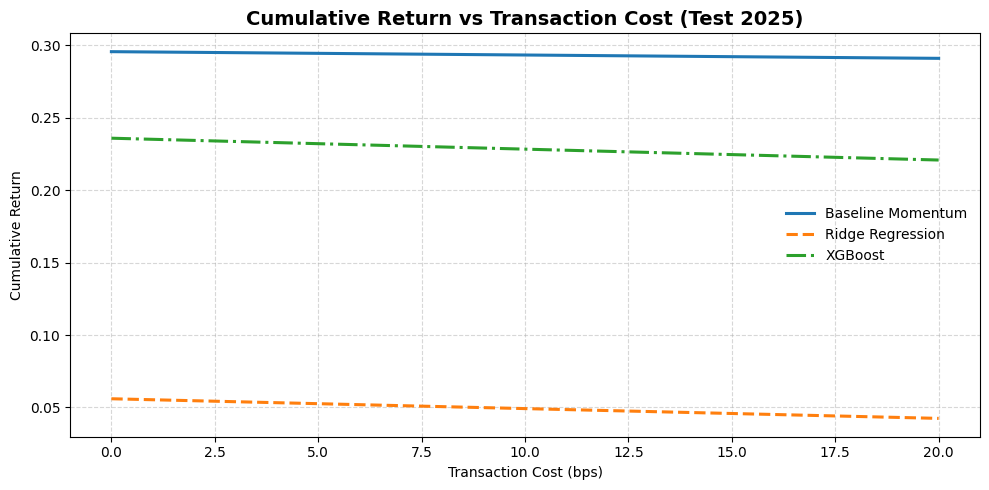

In [10]:
cost_bps = [0, 10, 20]

baseline_cum = [
    base_costs["cost_0bps"]["cumulative_return"],
    base_costs["cost_10bps"]["cumulative_return"],
    base_costs["cost_20bps"]["cumulative_return"],
]

ridge_cum = [
    ridge_costs["cost_0bps"]["cumulative_return"],
    ridge_costs["cost_10bps"]["cumulative_return"],
    ridge_costs["cost_20bps"]["cumulative_return"],
]

xgb_cum = [
    xgb_costs["cost_0bps"]["cumulative_return"],
    xgb_costs["cost_10bps"]["cumulative_return"],
    xgb_costs["cost_20bps"]["cumulative_return"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle="-.")
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Plot Sharpe ratio vs transaction cost

This shows whether risk-adjusted performance remains strong after costs.

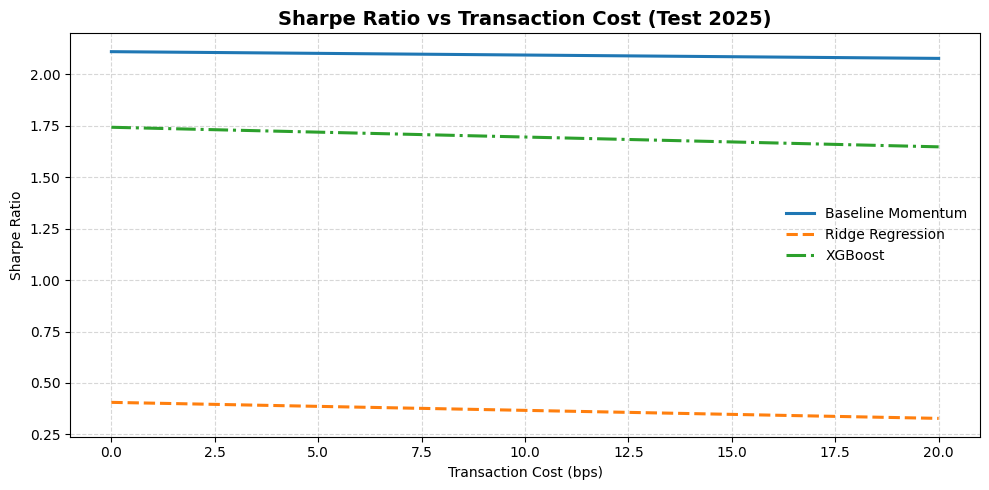

In [11]:
baseline_sharpe = [
    base_costs["cost_0bps"]["sharpe_ratio"],
    base_costs["cost_10bps"]["sharpe_ratio"],
    base_costs["cost_20bps"]["sharpe_ratio"],
]

ridge_sharpe = [
    ridge_costs["cost_0bps"]["sharpe_ratio"],
    ridge_costs["cost_10bps"]["sharpe_ratio"],
    ridge_costs["cost_20bps"]["sharpe_ratio"],
]

xgb_sharpe = [
    xgb_costs["cost_0bps"]["sharpe_ratio"],
    xgb_costs["cost_10bps"]["sharpe_ratio"],
    xgb_costs["cost_20bps"]["sharpe_ratio"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle="-.")
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Save tables and figures

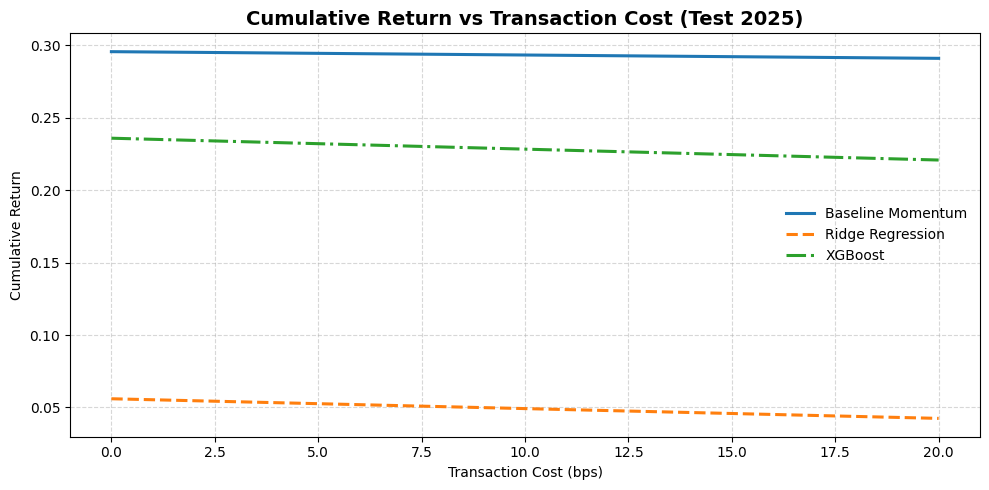

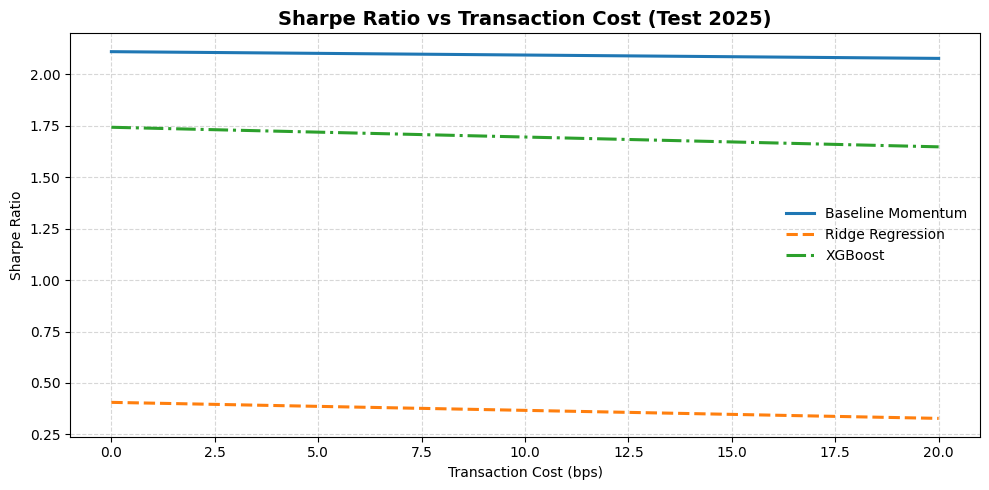

Saved figures and tables to: reports/figures/results_cost_comparison


In [12]:
OUT_DIR = "reports/figures/results_cost_comparison"
os.makedirs(OUT_DIR, exist_ok=True)

cost_table.to_csv(os.path.join(OUT_DIR, "cost_comparison_full_table.csv"), index=False)
summary_table.to_csv(os.path.join(OUT_DIR, "cost_comparison_summary.csv"), index=False)

# Save cumulative return plot
plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle="-.")
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cumulative_return_vs_cost.png"), dpi=300)
plt.show()

# Save Sharpe plot
plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle="-.")
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sharpe_vs_cost.png"), dpi=300)
plt.show()

print("Saved figures and tables to:", OUT_DIR)

## 7. Interpretation

Key practical observations:

- **Baseline momentum** is the most robust to transaction costs because it has the lowest turnover.
- **Ridge regression** deteriorates the most after costs, confirming that weak predictive signal plus high turnover makes it impractical.
- **XGBoost** remains much stronger than Ridge after costs, but still does not exceed the baseline in the 2025 hold-out year.
- This shows that stronger ML models may improve ranking performance, but practical usefulness still depends heavily on turnover and implementation frictions.